# Descriptor ORB y Matching

Interpretación práctica
Distancia de Hamming:

0-50: Match excelente (muy similar)

50-100: Match bueno

100-150: Match aceptable

\>150: Match débil (probablemente falso positivo)

Calidad de keypoints:

response: Mayor valor = característica más distintiva

size: Área del parche analizado (mayor para escalas más gruesas)

angle: Orientación dominante (0-360 grados)

Distribución de bits:

Ideal: ~50% de bits en 1 y 50% en 0

Si hay muchos 0 o muchos 1, el descriptor es pobre

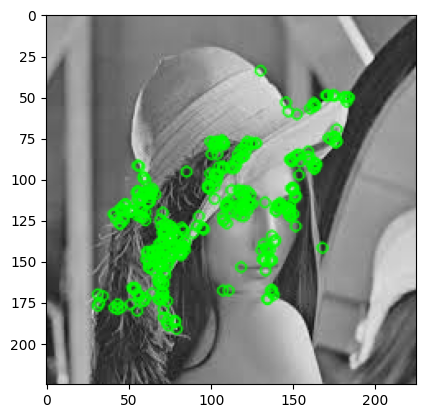

(<matplotlib.image.AxesImage at 0x7f193820b110>, None)

In [2]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('img/lena.jpeg', cv2.IMREAD_GRAYSCALE)

# Initiate ORB detector
orb = cv2.ORB_create()

# find the keypoints with ORB
kp = orb.detect(img,None)

# compute the descriptors with ORB
kp, des = orb.compute(img, kp)

# draw only keypoints location,not size and orientation
img2 = cv2.drawKeypoints(img, kp, None, color=(0,255,0), flags=0)
plt.imshow(img2), plt.show()

In [3]:
len(kp)

400

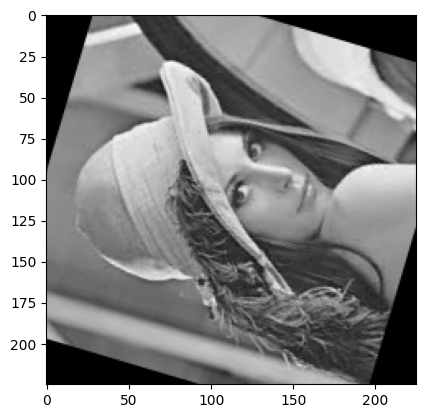

(<matplotlib.image.AxesImage at 0x7f19381664d0>, None)

In [4]:
h, w = img.shape
c = (h/2,w/2)
R = cv2.getRotationMatrix2D(c, 73.5, 1)
img_t = cv2.warpAffine(img, R, (w,h))
plt.imshow(img_t, cmap="gray"), plt.show()

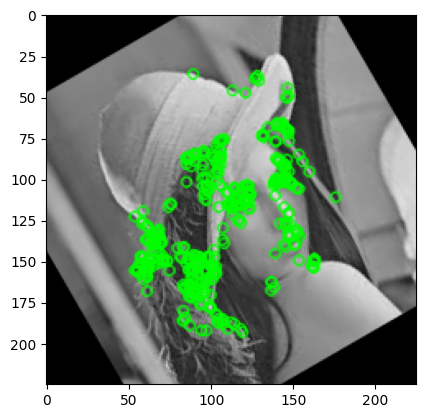

(<matplotlib.image.AxesImage at 0x7fed6c3ba710>, None)

In [57]:
kp2 = orb.detect(img_t,None)
kp2, des2 = orb.compute(img_t, kp2)
img2_t = cv2.drawKeypoints(img_t, kp2, None, color=(0,255,0), flags=0)
plt.imshow(img2_t), plt.show()

In [59]:
def visualize_matches(img1, kp1, desc1, img2, kp2, desc2, n_matches=20):
    """Visualiza los mejores matches entre dos imágenes"""
    
    # Matching
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(desc1, desc2)
    matches = sorted(matches, key=lambda x: x.distance)
    
    # Tomar los mejores n_matches
    good_matches = matches[:n_matches]
    
    # Filtrar por distancia (opcional)
    max_distance = good_matches[-1].distance
    print(f"Distancia mínima: {good_matches[0].distance}")
    print(f"Distancia máxima: {max_distance}")
    
    # Dibujar matches
    result = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    return (result, good_matches)

Distancia mínima: 7.0
Distancia máxima: 7.0


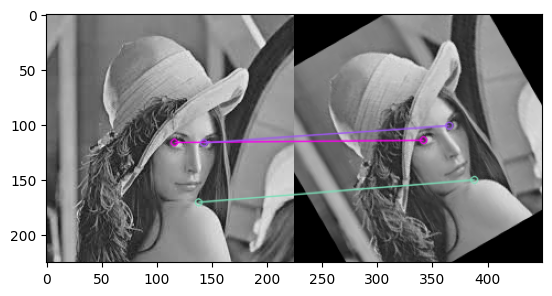

(<matplotlib.image.AxesImage at 0x7fed6c116510>, None)

In [62]:
img_match, good_matches = visualize_matches(img, kp, des, img_t, kp2, des2, 3)
plt.imshow(img_match), plt.show()

In [41]:
good_matches = good_matches[:3]
good_matches[0].queryIdx
good_matches[0].trainIdx
p1 = np.array([kp[good_matches[i].queryIdx].pt for i in range(3)])
p2 = np.array([kp2[good_matches[i].trainIdx].pt for i in range(3)])

In [43]:
p1

array([[116.        , 116.        ],
       [138.        , 170.40000916],
       [142.80000305, 116.40000153]])

In [ ]:
# Obtener la transformación afín usando los tres mejores matches con lena
# Usar getAffineTransform y warpAffine con los tres mejores matches